<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Autism Spectrum Disorder Prediction**

---

In [1]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [3]:
df = pd.read_csv('Autism Spectrum Disorder Prediction - Dataset.csv')
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [4]:
df.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,0,1,0,0,0,0,0,0,1,...,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,...,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,...,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,...,f,?,no,no,Canada,no,9.069342,18 and more,Self,0
799,800,0,1,0,0,0,0,0,0,0,...,f,?,no,no,United Arab Emirates,yes,2.243304,18 and more,Self,0


In [5]:
df.shape

(800, 22)

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [9]:
df['age'] = df['age'].astype(int)

In [10]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [11]:
for col in df.columns:
    numerical_features = ['ID', 'age', 'result']
    if col not in numerical_features:
        print(col, df[col].unique())
        print("--" * 20)

A1_Score [1 0]
----------------------------------------
A2_Score [0 1]
----------------------------------------
A3_Score [1 0]
----------------------------------------
A4_Score [0 1]
----------------------------------------
A5_Score [1 0]
----------------------------------------
A6_Score [0 1]
----------------------------------------
A7_Score [1 0]
----------------------------------------
A8_Score [0 1]
----------------------------------------
A9_Score [1 0]
----------------------------------------
A10_Score [1 0]
----------------------------------------
gender ['f' 'm']
----------------------------------------
ethnicity ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
----------------------------------------
jaundice ['no' 'yes']
----------------------------------------
austim ['no' 'yes']
----------------------------------------
contry_of_res ['Austria' 'India' 'United States' 'South Africa' 'Jordan'
 '

In [12]:
df = df.drop(columns = ['ID', 'age_desc'])

In [13]:
df.shape

(800, 20)

In [14]:
df = df.rename(columns = {'contry_of_res': 'country_of_res'})

In [15]:
df['country_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [16]:
country_map = {'Viet Nam': 'Vietnam',
               'AmericanSamoa': 'United States',
               'Hong Kong': 'China'}

df['country_of_res'] = df['country_of_res'].replace(country_map)

In [17]:
df['country_of_res'].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

In [18]:
df['Class/ASD'].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

In [19]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


Age Mean:  27.96375
Age Median:  24.0


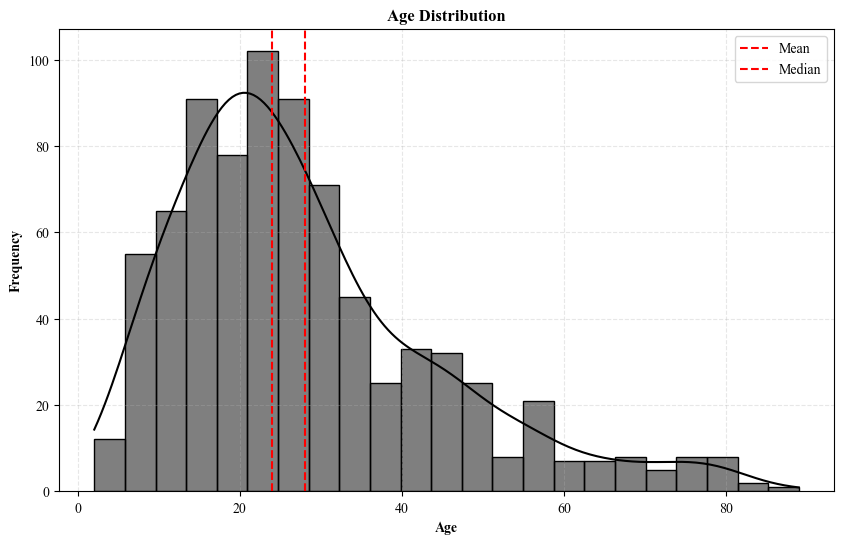

In [20]:
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['age'], kde = True, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Age Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
age_mean = df['age'].mean()
age_median = df['age'].median()
print('Age Mean: ', age_mean)
print('Age Median: ', age_median)
ax.axvline(age_mean, color = 'red', linestyle = '--', label = 'Mean')
ax.axvline(age_median, color = 'red', linestyle = '--', label = 'Median')
ax.legend()
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

Result Mean:  8.537303106501248
Result Median:  9.605299308


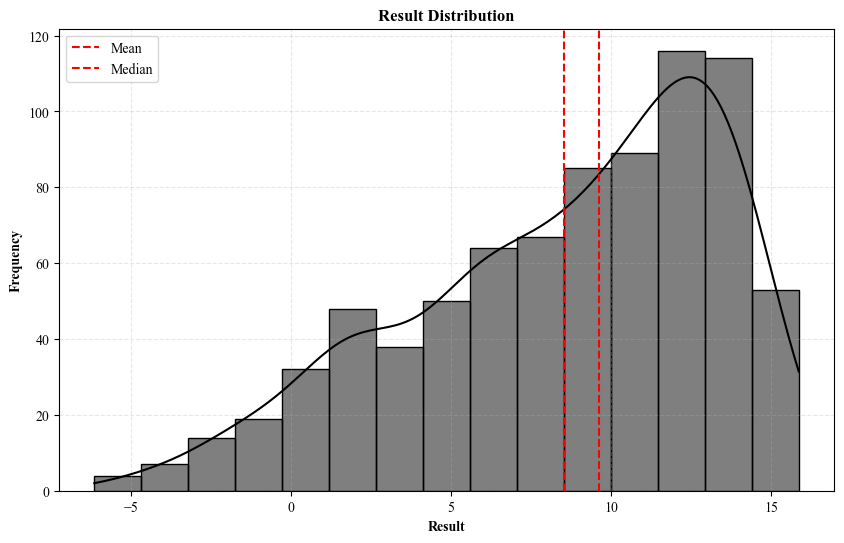

In [21]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.histplot(df['result'], kde = True, color = 'black', edgecolor = 'black', ax = ax)
ax.set_title('Result Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Result', fontweight = 'bold')
ax.set_ylabel('Frequency', fontweight = 'bold')
result_mean = df['result'].mean()
result_median = df['result'].median()
print('Result Mean: ', result_mean)
print('Result Median: ', result_median)
ax.axvline(result_mean, color = 'red', linestyle = '--', label = 'Mean')
ax.axvline(result_median, color = 'red', linestyle = '--', label = 'Median')
ax.legend()
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

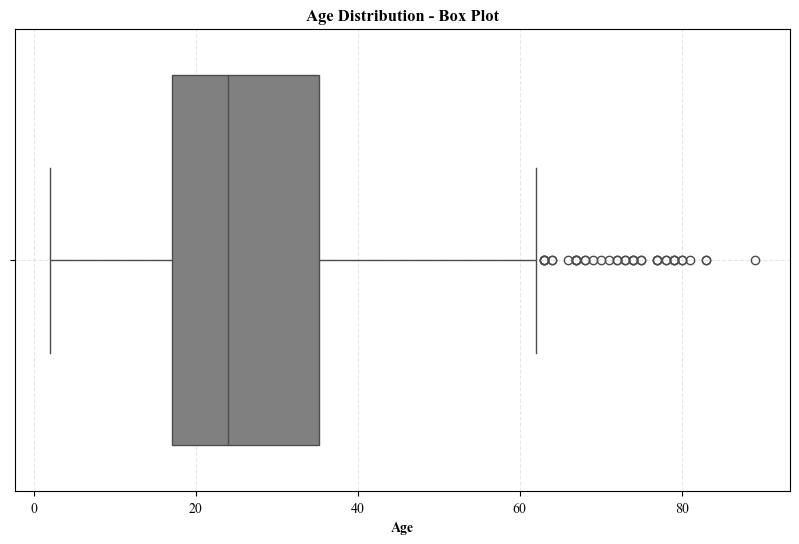

In [22]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['age'], color = 'grey', ax = ax)
ax.set_title('Age Distribution - Box Plot', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

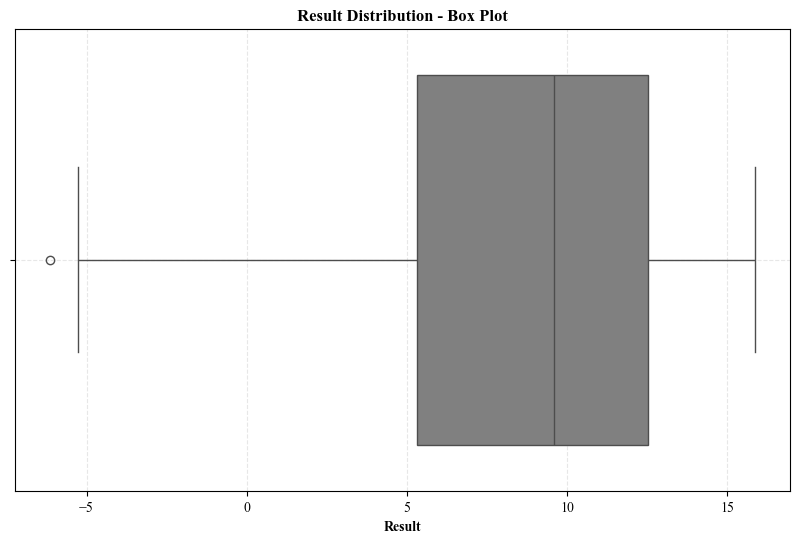

In [23]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(x = df['result'], color = 'grey', ax = ax)
ax.set_title('Result Distribution - Box Plot', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Result', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [24]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

age_outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print('Lower Bound: ', lower_bound)
print('Upper Bound: ', upper_bound)
print('Number of Outliers (Age): ', len(age_outliers))

Lower Bound:  -10.375
Upper Bound:  62.625
Number of Outliers (Age):  39


In [25]:
Q1 = df['result'].quantile(0.25)
Q3 = df['result'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

result_outliers = df[(df['result'] < lower_bound) | (df['result'] > upper_bound)]

print('Lower Bound: ', lower_bound)
print('Upper Bound: ', upper_bound)
print('Number of Outliers (Result): ', len(result_outliers))

Lower Bound:  -5.5052896818749995
Upper Bound:  23.326348605125
Number of Outliers (Result):  1


In [26]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'country_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

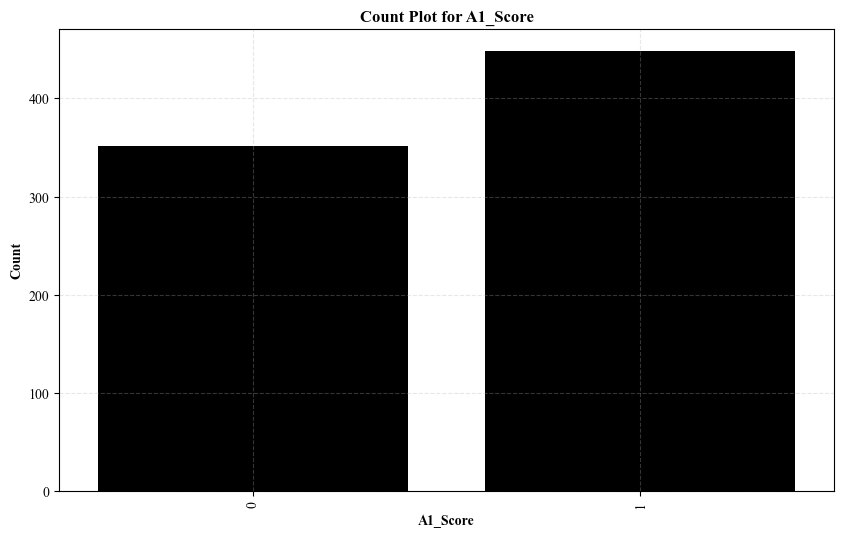

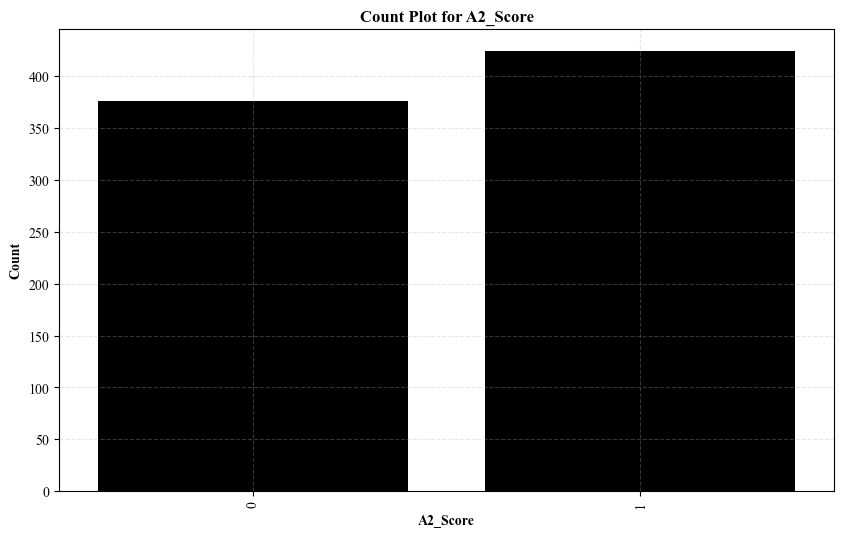

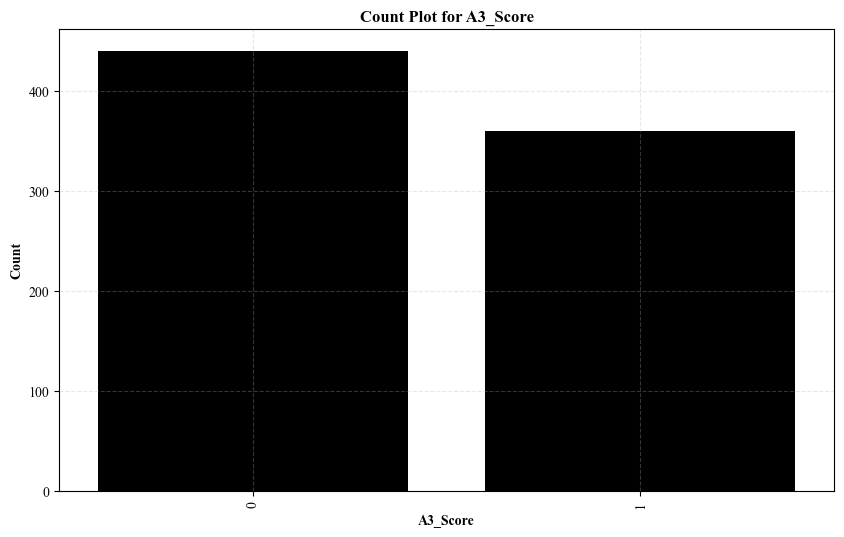

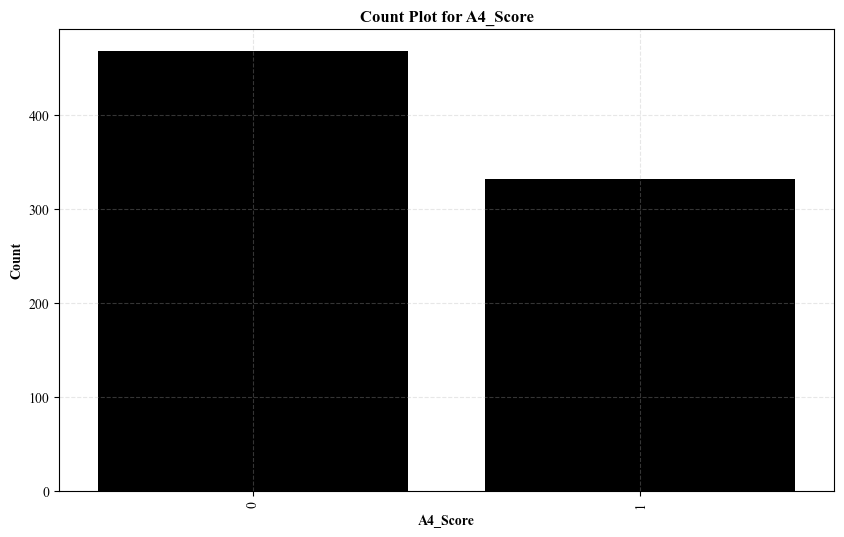

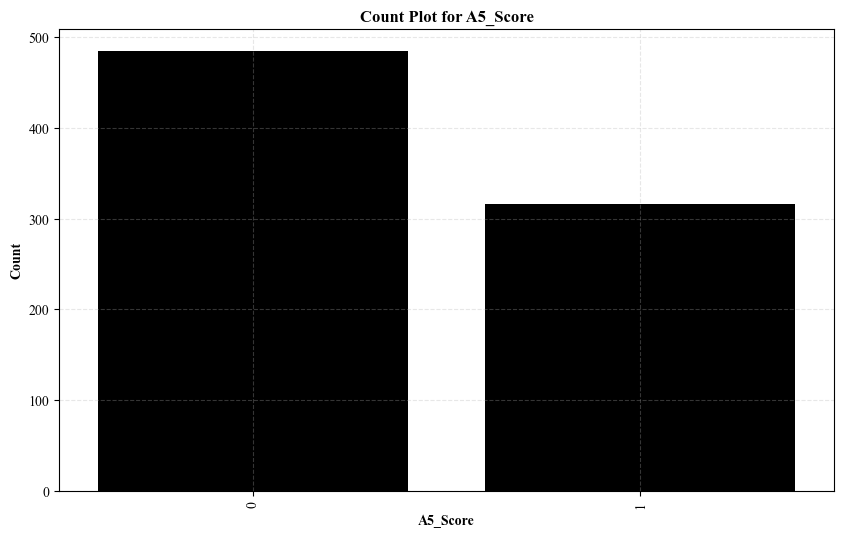

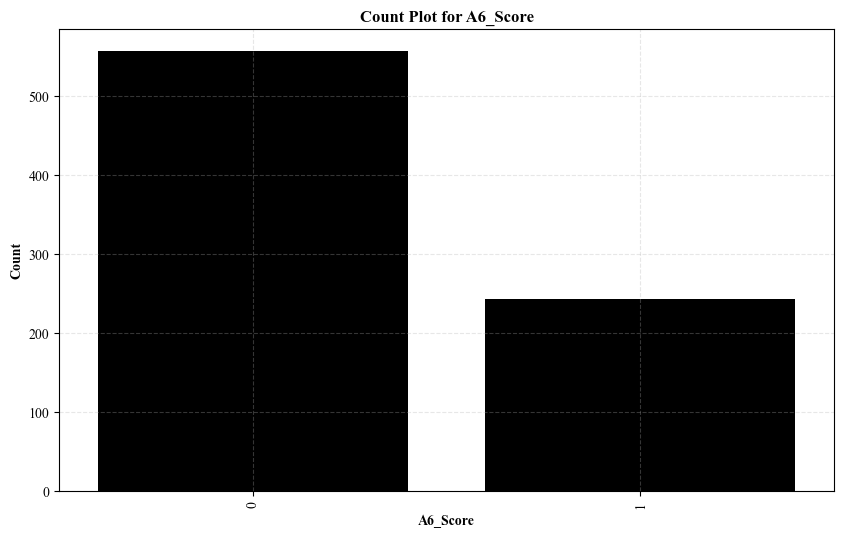

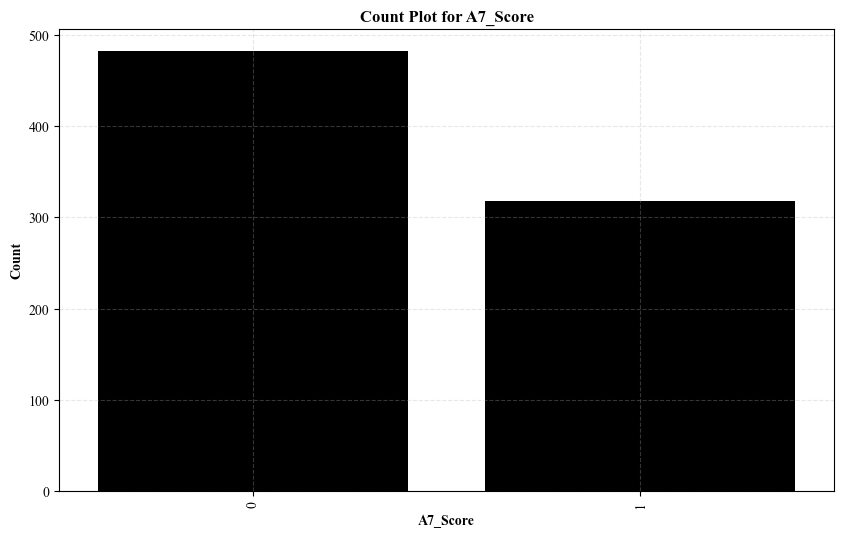

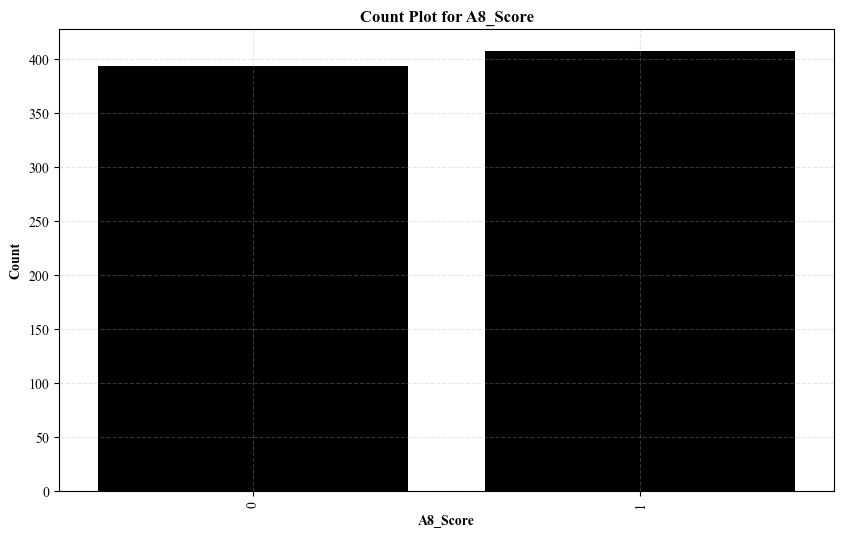

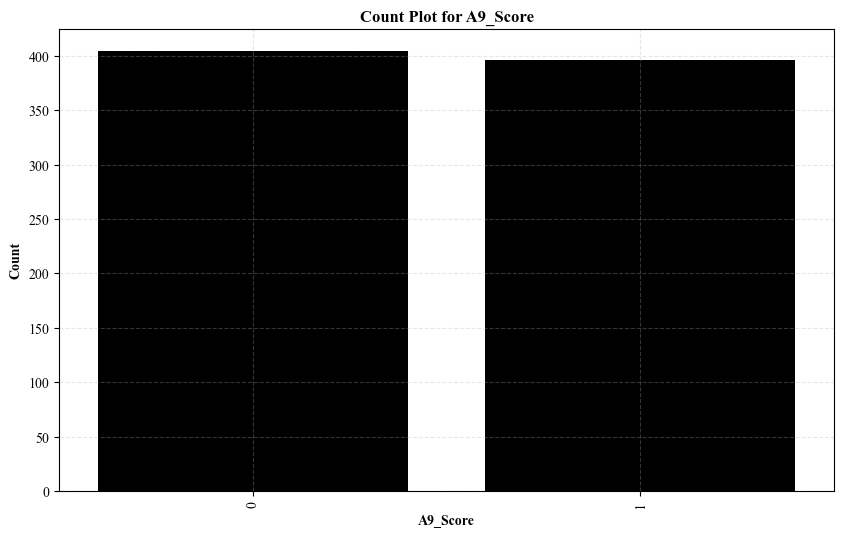

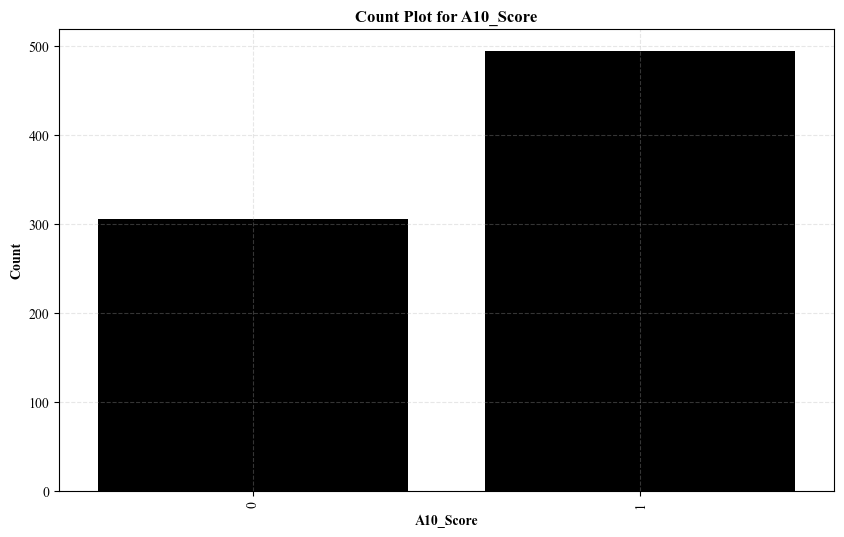

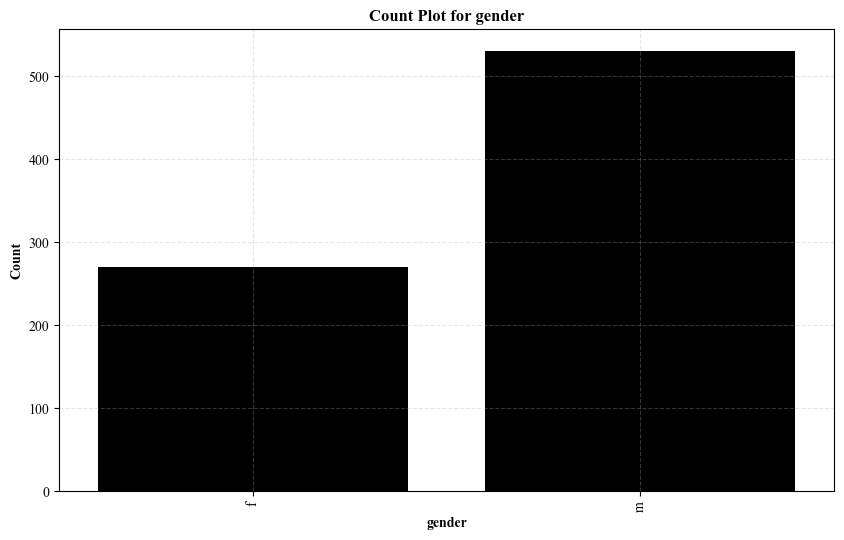

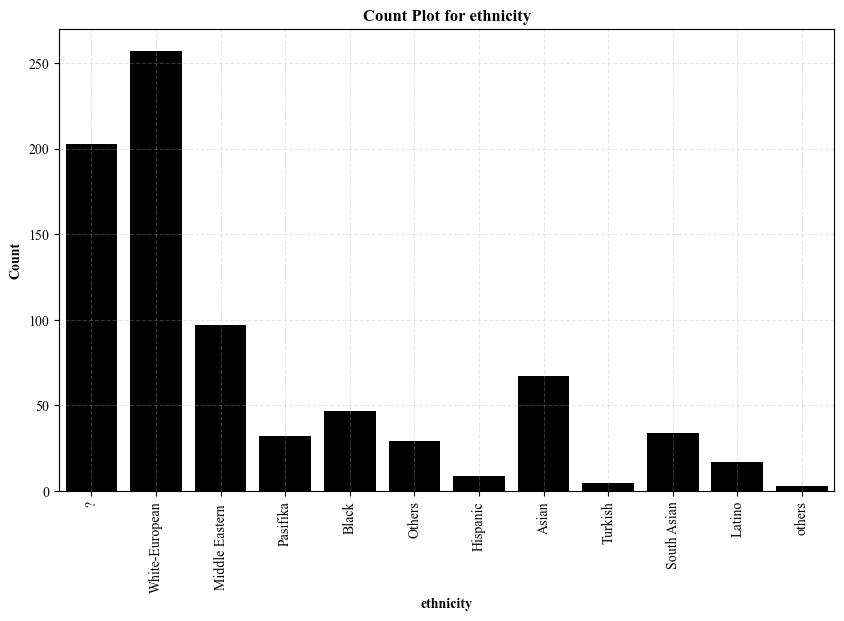

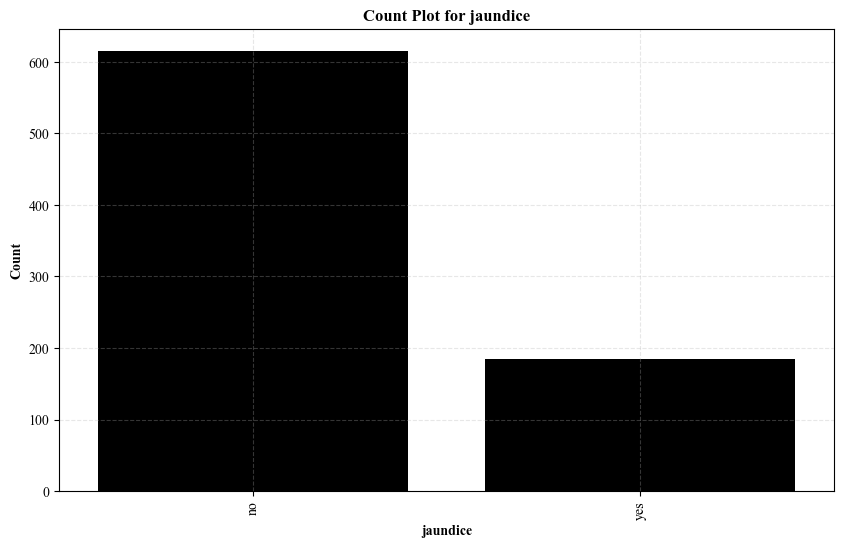

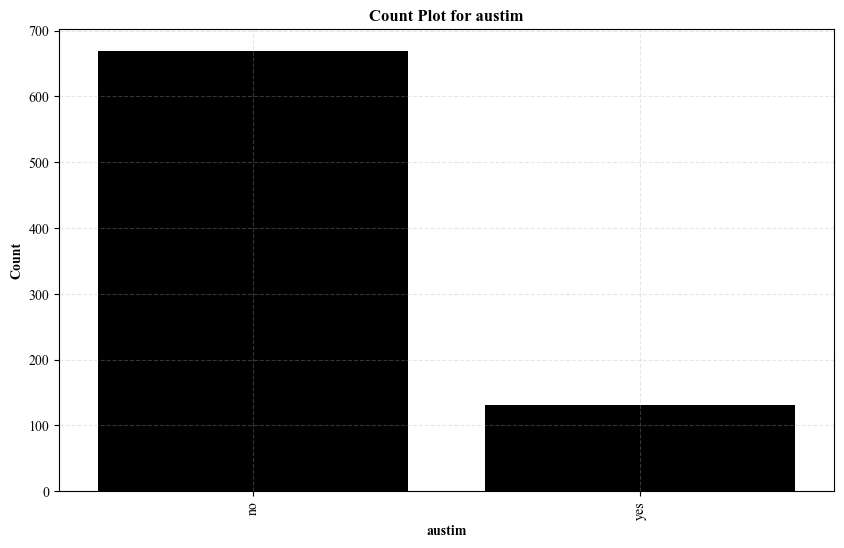

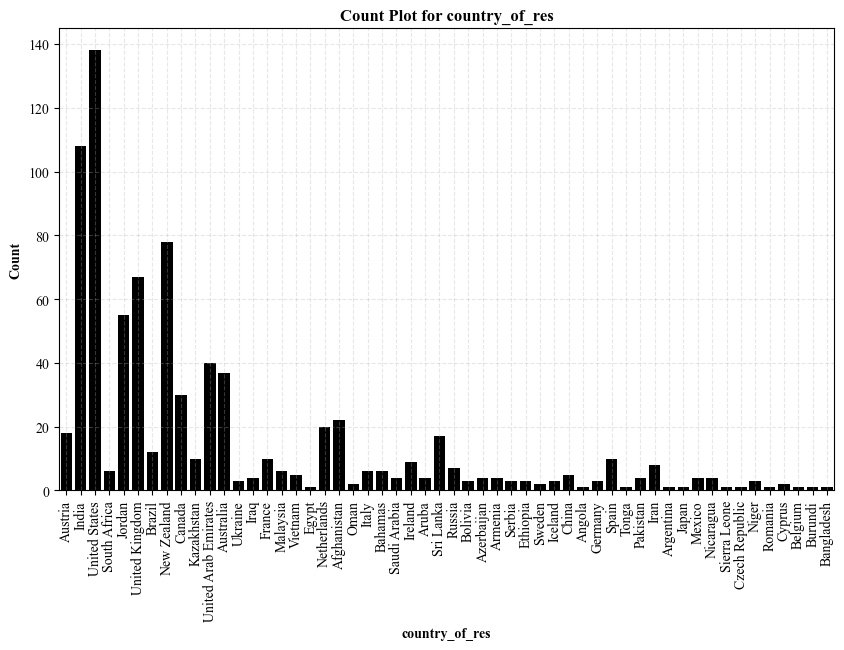

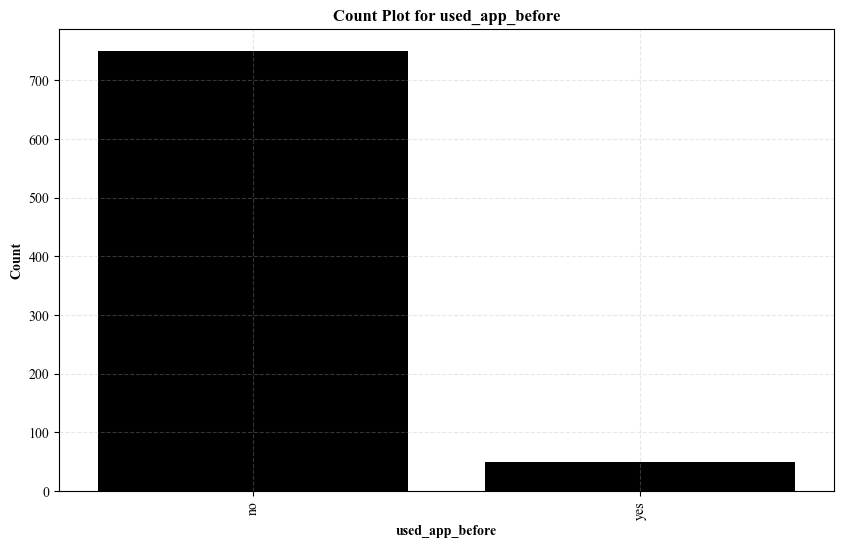

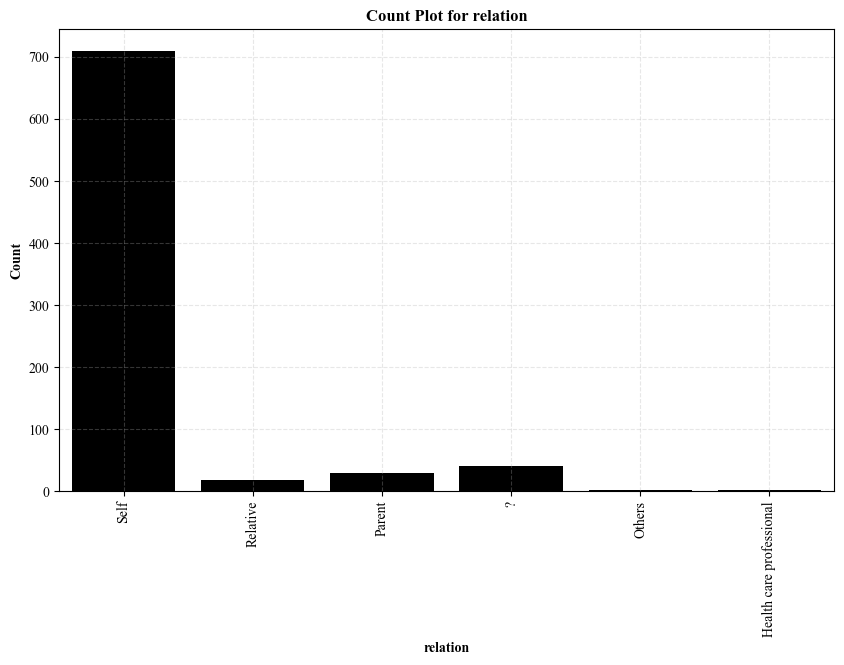

In [27]:
categorical_columns = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
                       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender', 'ethnicity',
                       'jaundice', 'austim', 'country_of_res', 'used_app_before', 'relation']

for col in categorical_columns:
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.countplot(x = df[col], color = 'black', ax = ax)
    ax.set_title(f'Count Plot for {col}', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(col, fontweight = 'bold')
    ax.set_ylabel('Count', fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    ax.tick_params(axis = 'x', rotation = 90)
    plt.show()

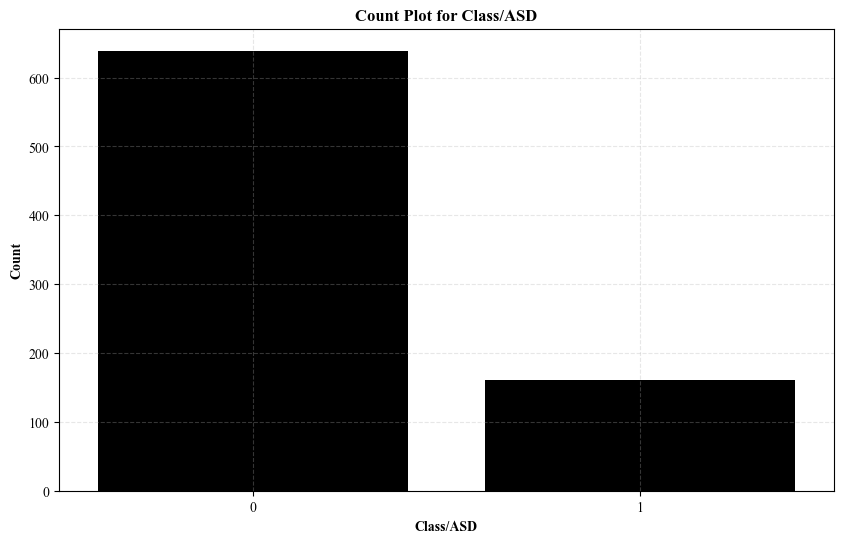

In [28]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.countplot(x = df['Class/ASD'], color = 'black', ax = ax)
ax.set_title('Count Plot for Class/ASD', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Class/ASD', fontweight = 'bold')
ax.set_ylabel('Count', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [29]:
for col in df.columns:
    numerical_features = ['ID', 'age', 'result']
    if col not in numerical_features:
        print(col, df[col].unique())
        print("--" * 20)

A1_Score [1 0]
----------------------------------------
A2_Score [0 1]
----------------------------------------
A3_Score [1 0]
----------------------------------------
A4_Score [0 1]
----------------------------------------
A5_Score [1 0]
----------------------------------------
A6_Score [0 1]
----------------------------------------
A7_Score [1 0]
----------------------------------------
A8_Score [0 1]
----------------------------------------
A9_Score [1 0]
----------------------------------------
A10_Score [1 0]
----------------------------------------
gender ['f' 'm']
----------------------------------------
ethnicity ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
----------------------------------------
jaundice ['no' 'yes']
----------------------------------------
austim ['no' 'yes']
----------------------------------------
country_of_res ['Austria' 'India' 'United States' 'South Africa' 'Jordan'
 

In [30]:
df['ethnicity'] = df['ethnicity'].replace({'?': 'Others', 'others': 'Others'})
df['ethnicity'].unique()

array(['Others', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [31]:
df['relation'] = df['relation'].replace({'?': 'Others', 
                                         'Relative': 'Others', 
                                         'Parent': 'Others',
                                         'Health care professional': 'Others'})
df['relation'].unique()

array(['Self', 'Others'], dtype=object)

In [32]:
object_columns = df.select_dtypes(include = ['object']).columns
object_columns

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'country_of_res',
       'used_app_before', 'relation'],
      dtype='object')

In [33]:
encoders = {}

for column in object_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'country_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

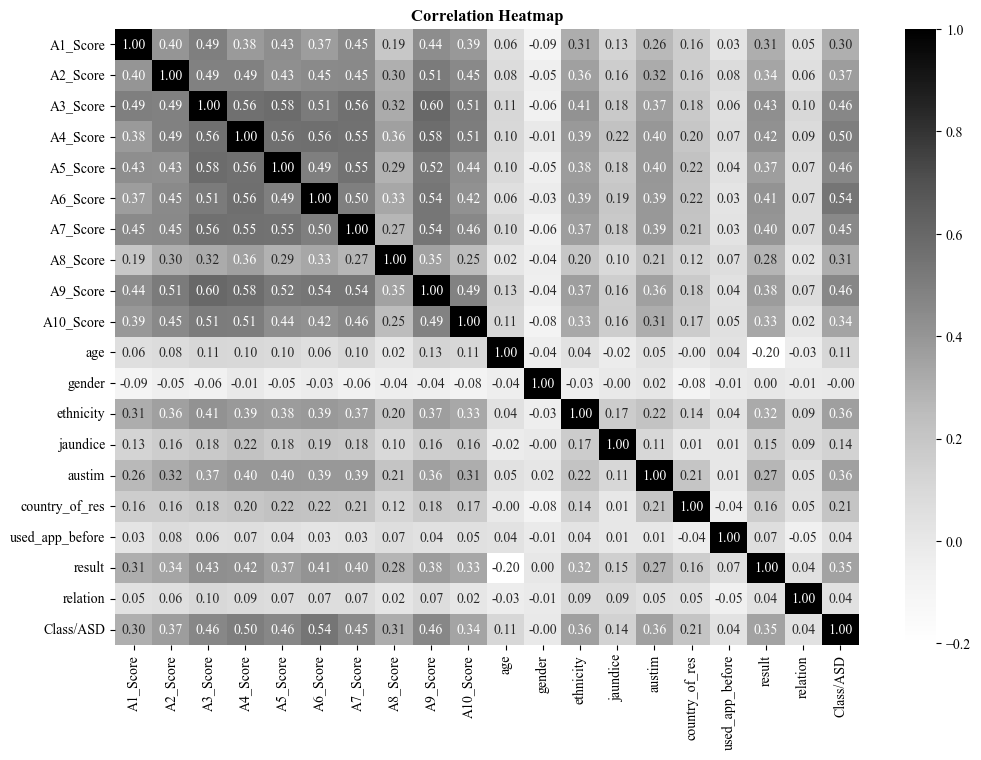

In [34]:
fig, ax = plt.subplots(figsize = (12, 8))
sns.heatmap(df.corr(), annot = True, cmap = 'Greys', fmt = '.2f', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [35]:
def outlier_imputation_median(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median = df[column].median()
    df[column] = df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
    return df

df = outlier_imputation_median(df, 'age')
df = outlier_imputation_median(df, 'result')

df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,country_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1,0


In [36]:
X = df.drop(columns = ['Class/ASD'])
y = df['Class/ASD']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(640, 19) (160, 19) (640,) (160,)


In [38]:
y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

In [39]:
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(y_train_smote.shape)

(1030,)


In [40]:
models = {'Decision Tree': DecisionTreeClassifier(random_state = 42),
          'Random Forest': RandomForestClassifier(random_state = 42),
          'XGBoost': XGBClassifier(random_state = 42)}

cv_scores = {}

for model_name, model in models.items():
    print(f'Training {model_name} using default parameters')
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv = 5, scoring = 'accuracy')
    cv_scores[model_name] = scores
    print(f'{model_name} Cross-Validation Accuracy: {np.mean(scores): .2f}')
    print('--' * 20)

Training Decision Tree using default parameters
Decision Tree Cross-Validation Accuracy:  0.86
----------------------------------------
Training Random Forest using default parameters
Random Forest Cross-Validation Accuracy:  0.92
----------------------------------------
Training XGBoost using default parameters
XGBoost Cross-Validation Accuracy:  0.90
----------------------------------------


In [41]:
cv_scores

{'Decision Tree': array([0.7961165 , 0.87864078, 0.87378641, 0.8592233 , 0.87378641]),
 'Random Forest': array([0.90776699, 0.92718447, 0.9223301 , 0.91747573, 0.9223301 ]),
 'XGBoost': array([0.86893204, 0.9223301 , 0.90776699, 0.90776699, 0.91262136])}

In [42]:
for model_name, scores in cv_scores.items():
    print(f'{model_name} Average Cross-Validation Score: {scores.mean(): .4f}')

Decision Tree Average Cross-Validation Score:  0.8563
Random Forest Average Cross-Validation Score:  0.9194
XGBoost Average Cross-Validation Score:  0.9039


In [43]:
dt = DecisionTreeClassifier(random_state = 42)

dt_params = {'criterion': ['gini', 'entropy'],
             'max_depth': [None, 10, 20, 30, 50, 70],
             'min_samples_split': [2, 5, 10],
             'min_samples_leaf': [1, 2, 4]}

random_search_dt = RandomizedSearchCV(estimator = dt, param_distributions = dt_params,
                                      n_iter = 20, cv = 5, scoring = 'accuracy', random_state = 42)

random_search_dt.fit(X_train_smote, y_train_smote)

C:\Users\dilan\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30, 50, 70],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')

In [44]:
dt = random_search_dt.best_estimator_
y_pred = dt.predict(X_test)
print('Decision Tree')
print(f'Training Accuracy: {accuracy_score(y_train_smote, dt.predict(X_train_smote))}')
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, dt.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Decision Tree
Training Accuracy: 1.0
Test Accuracy: 0.775
Confusion Matrix: [[106  18]
 [ 18  18]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85       124
           1       0.50      0.50      0.50        36

    accuracy                           0.78       160
   macro avg       0.68      0.68      0.68       160
weighted avg       0.78      0.78      0.78       160



In [45]:
rf = RandomForestClassifier(random_state = 42)

rf_params = {'n_estimators': [50, 100, 200],
             'max_depth': [None, 10, 20, 30],
             'min_samples_split': [2, 5, 10],
             'min_samples_leaf': [1, 2, 4],
             'bootstrap': [True, False]}

random_search_rf = RandomizedSearchCV(estimator = rf, param_distributions = rf_params,
                                      n_iter = 20, cv = 5, scoring = 'accuracy', random_state = 42)

random_search_rf.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy')

In [46]:
rf = random_search_rf.best_estimator_
y_pred = rf.predict(X_test)
print('Random Forest')
print(f'Training Accuracy: {accuracy_score(y_train_smote, rf.predict(X_train_smote))}')
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, rf.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Random Forest
Training Accuracy: 1.0
Test Accuracy: 0.825
Confusion Matrix: [[109  15]
 [ 13  23]]
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.88      0.89       124
           1       0.61      0.64      0.62        36

    accuracy                           0.82       160
   macro avg       0.75      0.76      0.75       160
weighted avg       0.83      0.82      0.83       160



In [47]:
xgb = XGBClassifier(random_state = 42)

xgb_params = {'n_estimators': [50, 100, 200, 500],
              'max_depth': [3, 5, 7, 10],
              'learning_rate': [0.01, 0.1, 0.2, 0.3],
              'subsample': [0.5, 0.7, 1.0],
              'colsample_bytree': [0.5, 0.7, 1.0]}

random_search_xgb = RandomizedSearchCV(estimator = xgb, param_distributions = xgb_params, 
                                       n_iter = 20, cv = 5, scoring = 'accuracy', random_state = 42)

random_search_xgb.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [48]:
xgb = random_search_xgb.best_estimator_
y_pred = xgb.predict(X_test)
print('XGBoost Classifier')
print(f'Training Accuracy: {accuracy_score(y_train_smote, xgb.predict(X_train_smote))}')
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, xgb.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

XGBoost Classifier
Training Accuracy: 1.0
Test Accuracy: 0.8125
Confusion Matrix: [[108  16]
 [ 14  22]]
Classification Report:               precision    recall  f1-score   support

           0       0.89      0.87      0.88       124
           1       0.58      0.61      0.59        36

    accuracy                           0.81       160
   macro avg       0.73      0.74      0.74       160
weighted avg       0.82      0.81      0.81       160



In [49]:
models = pd.DataFrame({'Model': ['Decision Tree',
                                 'Random Forest',
                                 'XGBoost Classifier'],
                       
                       'Score': [100 * round(dt_acc, 4),
                                 100 * round(rf_acc, 4),
                                 100 * round(xgb_acc, 4)]})

models.sort_values(by = 'Score', ascending = False)

,Model,Score
1,Random Forest,82.50
2,XGBoost Classifier,81.25
0,Decision Tree,77.50


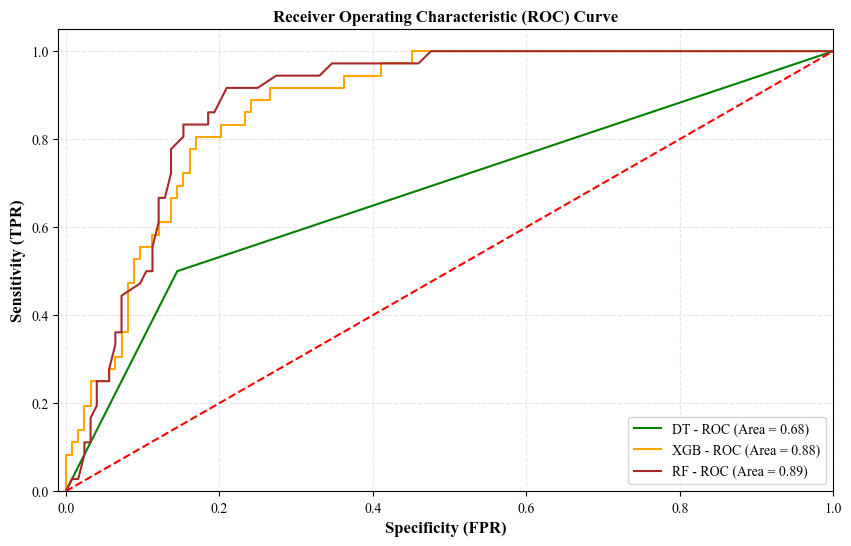

In [50]:
from sklearn import metrics

fig, ax = plt.subplots(figsize = (10, 6))

models = [{'label': 'DT', 'model': dt, 'color': 'green'},
          {'label': 'XGB', 'model': xgb, 'color': 'orange'},
          {'label': 'RF', 'model': rf, 'color': 'brown'}]

for m in models:
    model = m['model']
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
    auc = metrics.roc_auc_score(y_test, y_pred)
    ax.plot(fpr, tpr, label = '%s - ROC (Area = %0.2f)' % (m['label'], auc), color = m['color'])

ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Specificity (FPR)', fontweight = 'bold', fontsize = 12)
ax.set_ylabel('Sensitivity (TPR)', fontweight = 'bold', fontsize = 12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontweight = 'bold', fontsize = 12)
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend(loc = "lower right", fontsize = 10)

plt.show()

In [53]:
best_model = None
best_score = 0

if random_search_dt.best_score_ > best_score:
    best_model = random_search_dt.best_estimator_
    best_score = random_search_dt.best_score_

if random_search_rf.best_score_ > best_score:
    best_model = random_search_rf.best_estimator_
    best_score = random_search_rf.best_score_

if random_search_xgb.best_score_ > best_score:
    best_model = random_search_xgb.best_estimator_
    best_score = random_search_xgb.best_score_

best_model

RandomForestClassifier(bootstrap=False, max_depth=30, random_state=42)